In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [75]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\transmarcas\Export.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26899 entries, 0 to 26898
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  26899 non-null  str  
 1   Message  26899 non-null  str  
 2   Status   26899 non-null  str  
dtypes: str(3)
memory usage: 630.6 KB


In [76]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252501    10036
0x252511     9825
0x252513     6557
0x252514      481
Name: count, dtype: int64

In [77]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 26899 entries, 0 to 26898
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  26899 non-null  str  
 1   Message  26899 non-null  str  
 2   Status   26899 non-null  str  
 3   Headers  26899 non-null  str  
dtypes: str(4)
memory usage: 840.7 KB


Odometer

In [78]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 7038 entries, 24999 to 25720
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             7038 non-null   str  
 1   Message             7038 non-null   str  
 2   Status              7038 non-null   str  
 3   Headers             7038 non-null   str  
 4   Odometer in meters  7038 non-null   int64
 5   Date                7038 non-null   str  
 6   Raw data            7038 non-null   str  
dtypes: int64(1), str(6)
memory usage: 439.9 KB
None


000101000004 -> 0 -> 341536.0 -> 0x252514005901C70869487063243751003C38402D00000000EF00000007000061000000FFFFFFFFFFFFFFFFFFFF168000053620960001010000043333ED43531D93C2E26A88400000000003891252FFFFFF00001CFFFFFFFFFF
000101000004 -> 1 -> 341434.0 -> 0x2525140059001D0869487063243751003C38402D00000000F100000007000061000000FFFFFFFFFFFFFFFFFFFF1680000535BA1000010100000466E60244951D93C2EF6A88400000000003141236FFFFFF000020FFFFFFFFFF
000101000005 -> 2 -> 341536.0 -> 0x252514005901210869487063243751003C38402D00000000EF00000007000061000000FFFFFFFFFFFFFFFFFFFF168000053620920001010000053333ED43531D93C2E26A88400000000003871236FFFFFF000028FFFFFFFFFF
000101000005 -> 3 -> 341536.0 -> 0x2525140059012D0869487063243751003C38402D00000000EF00000007000061000000FFFFFFFFFFFFFFFFFFFF168000053620920001010000053333ED43531D93C2E26A88400000000003871255FFFFFF000026FFFFFFFFFF
000101000005 -> 4 -> 341536.0 -> 0x252514005901410869487063243751003C38402D00000000EF00000007000061000000FFFFFFFFFFFFFFFFFFFF1680000536209500010

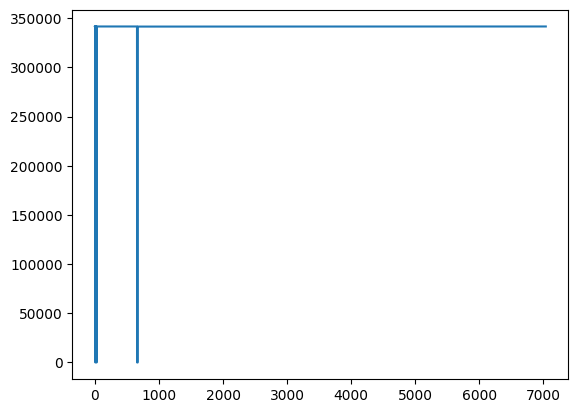

In [79]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [80]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


...


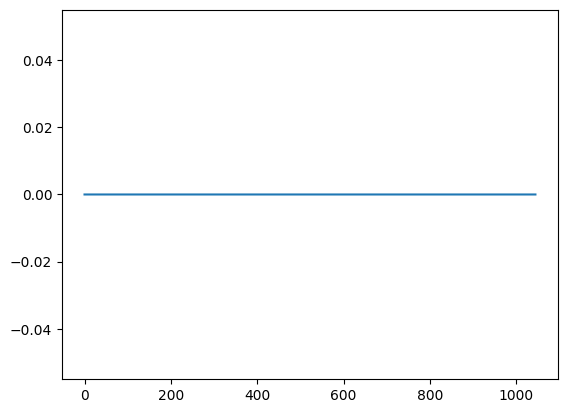

In [81]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])
    print(raw_data_[i])

plt.plot(x_axis,y_axis)

Satellites

In [82]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)
unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<1:
        num_events=num_events+1
        print(unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,5],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 7038 entries, 24999 to 25720
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         7038 non-null   str  
 1   Message                         7038 non-null   str  
 2   Status                          7038 non-null   str  
 3   Headers                         7038 non-null   str  
 4   Satellites                      7038 non-null   int64
 5   Satellite_connection_indicator  7038 non-null   int64
 6   Raw data                        7038 non-null   str  
 7   date                            7038 non-null   str  
dtypes: int64(2), str(6)
memory usage: 494.9 KB
2026-07-29 11:41:01.965 -> 0 -> 128 -> 0x252514005901720869487063243751003C38402D00000064A000000007000020000000FFFFFFFFFFFFFFFFFFFF17C0000536209100010100000902DC006501B61FA9000000000000000003871266FFFFFF000020FFFFFFFFFF
2026-07-29 11:20:15.036 -> 0 -> 128 -> 0x252514

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [83]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16)))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

#in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 7038 entries, 17 to 26890
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  7038 non-null   str  
 1   Message  7038 non-null   str  
 2   Status   7038 non-null   str  
 3   Headers  7038 non-null   str  
dtypes: str(4)
memory usage: 274.9 KB


Power

In [84]:
ext_bat_13=raw_data[raw_data['Status'].str.contains('0x252513')]
ext_bat_14=raw_data[raw_data['Status'].str.contains('0x252514')]
ext_bat_vol=pd.concat([ext_bat_13,ext_bat_14])
ext_bat=[]
date_bat=[]
bat_df=pd.DataFrame()

ext_bat_vol.info()

for i in range(0,ext_bat_vol.shape[0]):
    val=(float(ext_bat_vol.iloc[i,2][154:158]))/100
    date_bat.append(ext_bat_vol.iloc[i,2][106:119])
    ext_bat.append(val)
#print(ext_bat)

for i in range(0,ext_bat_vol.shape[0]):
    if ext_bat[i]<3:
        bat_df['Date']=date_bat
        bat_df['int_bat']=ext_bat

print(bat_df)

<class 'pandas.DataFrame'>
Index: 7038 entries, 17 to 26890
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  7038 non-null   str  
 1   Message  7038 non-null   str  
 2   Status   7038 non-null   str  
 3   Headers  7038 non-null   str  
dtypes: str(4)
memory usage: 274.9 KB
               Date  int_bat
0     2606042238296    12.69
1     2606042239446    12.72
2     2606042300046    12.60
3     2606042302030    12.62
4     2606042303030    12.62
...             ...      ...
7033  0001041815288    14.07
7034  0001042016368    12.92
7035  0001042122468    13.73
7036  0001051421078    12.85
7037  0001051525578    13.63

[7038 rows x 2 columns]


Pánico

In [85]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]

unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    #aux_raw_data.append(aux_cad[i])
    if aux_value=='03':
        print(aux_value, ' -> ',aux_date[i])    

print("len aux_cad: ",len(aux_cad))

<class 'pandas.DataFrame'>
Index: 7038 entries, 17 to 26890
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  7038 non-null   str  
 1   Message  7038 non-null   str  
 2   Status   7038 non-null   str  
 3   Headers  7038 non-null   str  
dtypes: str(4)
memory usage: 274.9 KB
len aux_cad:  7038
